In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module
import itertools

In [2]:
np.random.seed(3)  # reproducible connectivity + external events

# --- network size ---
N_PYR, N_PV, N_SST = 1000, 100, 100
N = N_PYR + N_PV + N_SST

ntwk = {
    # cell numbers
    'N_PYR': 1000,
    'N_PV': 100,
    'N_SST': 100,
    # connectivity probabilities
    # - from PYR
    'p_PYR_PYR' : 0.1,
    'p_PYR_PV' : 0.1,
    'p_PYR_SST' : 0.1,
    # - from PV
    'p_PV_PYR' : 0.15,
    'p_PV_PV' : 0.1,
    'p_PV_SST' : 0.1,
    # - from SST
    'p_SST_PYR' : 0.2,
    'p_SST_PV' : 0.1,
    'p_SST_SST' : 0.1,
}

# --- random recurrent connectivity matrix, 30% pairwise probability, no autapses ---
# indices of each population
N = ntwk['N_PYR'] + ntwk['N_PV'] + ntwk['N_SST']
ntwk['PYR'] = np.arange(ntwk['N_PYR'])
ntwk['PV'] = np.arange(ntwk['N_PYR'], ntwk['N_PYR']+ntwk['N_PV'])
ntwk['SST'] = np.arange(ntwk['N_PYR']+ntwk['N_PV'], ntwk['N_PYR']+ntwk['N_PV']+ntwk['N_SST'])


Text(0, 0.5, 'presynaptic neuron')

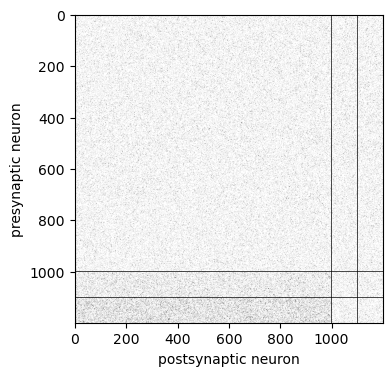

In [3]:
fig, ax_c = plt.subplots(figsize=(4,4))

conn = np.zeros((N, N))
# connectivity from pyramidal
for pre, post in itertools.product(['PYR', 'PV', 'SST'],
                                   ['PYR', 'PV', 'SST']):
    conn[np.ix_(ntwk[pre],ntwk[post])] = \
        np.random.rand(len(ntwk[pre]), len(ntwk[post])) < ntwk['p_%s_%s' % (pre, post)]
pre_idx, post_idx = np.nonzero(conn)
   
ax_c.imshow(conn, cmap='Greys', vmin=0, vmax=1)



for b in np.cumsum([ntwk['N_PYR'], ntwk['N_PV'], ntwk['N_SST']]):
    ax_c.axhline(b-0.5, color='k', lw=0.5); ax_c.axvline(b-0.5, color='k', lw=0.5)

ax_c.set_xlabel('postsynaptic neuron'); ax_c.set_ylabel('presynaptic neuron')

In [4]:
brian.start_scope()

tstop = 1e3 # 500mss (in ms by default)
f_ext = 1. # Hz

eqs = '''
dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
dg_e/dt   = -g_e   / tau_e : siemens
dg_i/dt   = -g_i   / tau_i : siemens
dg_ext/dt = -g_ext / tau_e : siemens
'''

pop = brian.NeuronGroup(N, eqs, threshold='v>Vt', reset='v=Vr',
                        refractory=Tr,
                        method='exponential_euler')
pop.v = El

is_exc_source = pre_idx < ntwk['N_PYR']
syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

# --- independent external excitatory events, 3-4 per neuron ---
ext_factors = np.zeros(N)
ext_factors[ntwk['PYR']] = 1.5      # for pyramidal neurons
ext_factors[~ntwk['PYR']] = 0.9    # for interneurons
ext_times =[
    np.cumsum(np.random.exponential(1e3/f_ext/f, int(f_ext*tstop))+1e-1)\
          for n, f in enumerate(ext_factors)
]

ext_times =[
    np.cumsum(np.random.exponential(1./f_ext, int(f_ext*tstop))+1e-1) for n in range(N)
]
ext_input = brian.SpikeGeneratorGroup(N, 
                    np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                    np.concatenate(ext_times)*ms)

syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

mon = brian.StateMonitor(pop, 'v',
                            record=np.concatenate([np.arange(6),
                                                   ntwk['N_PYR']+np.arange(2),
                                                   ntwk['N_PV']+ntwk['N_PYR']+np.arange(2)]))
spikes = brian.SpikeMonitor(pop)
ratePYR = brian.PopulationRateMonitor(pop[ntwk['PYR']])
ratePV = brian.PopulationRateMonitor(pop[ntwk['PV']])
rateSST = brian.PopulationRateMonitor(pop[ntwk['SST']])

brian.run(tstop*ms)

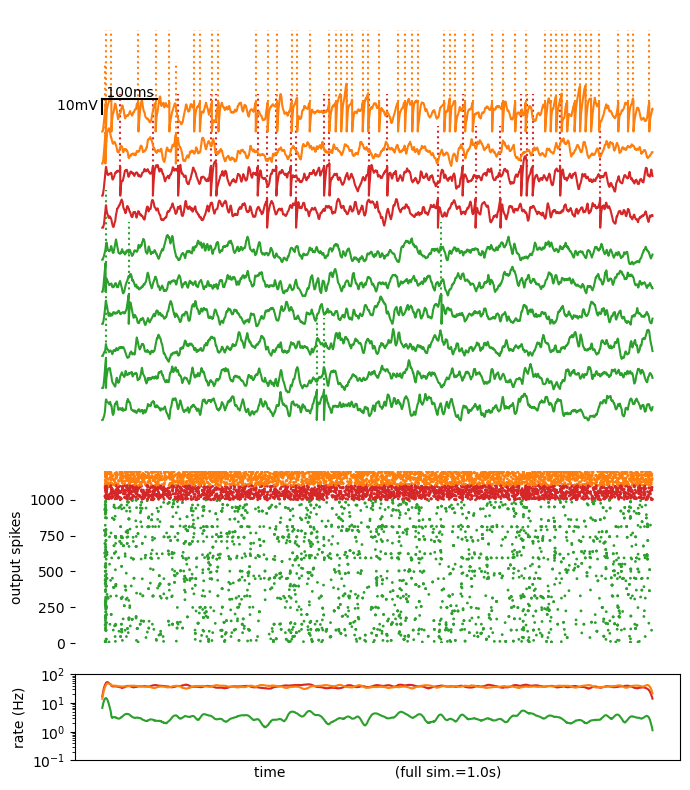

In [5]:
from plots import plot_with_spikes

def plot(mon, spikes, rates):

    # --- plot: connectivity matrix, voltage traces, raster ---
    fig = plt.figure(figsize=(7, 8))
    gs = fig.add_gridspec(3, 1,
                          height_ratios=[5, 2, 1])

    ax_v = fig.add_subplot(gs[0], frameon=False)
    colors = ['C2' for i in range(6)]+['C3', 'C3']+['C1', 'C1']
    for n in range(mon.v.shape[0]):
        plot_with_spikes(ax_v, mon, n, shift=n*22,
                         color=colors[n])

    # show bar scale
    ax_v.plot([0,0], El/mV+(n+2)*20-np.arange(2)*10, 'k-')
    ax_v.plot([0,100], El/mV+(n+2)*20-np.zeros(2), 'k-')
    ax_v.annotate('10mV ', (0,El/mV+(n+2)*20), va='top', ha='right', xycoords='data')
    ax_v.annotate(' 100ms', (0,El/mV+(n+2)*20+2), xycoords='data')
    ax_v.axis('off')

    ax_r = fig.add_subplot(gs[1], sharex=ax_v, frameon=False)
    # we randomly subsample spikes if they are too numerous for display
    spike_subsampling = np.random.choice(np.arange(len(spikes.i)),
                                         np.min([10000, len(spikes.i)]))
    def colors(n):
        if n<ntwk['N_PYR']:
            return 'C2'
        elif n>=ntwk['N_PYR']+ntwk['N_PV']:
            return 'C1'
        else:
            return 'C3'
    ax_r.scatter(spikes.t[spike_subsampling]/ms, spikes.i[spike_subsampling],
                 c=[colors(i) for i in spikes.i[spike_subsampling]], s=1)
    ax_r.set_ylabel('output spikes')
    ax_r.set_xticks([])
    ax_r.set_ylim([-1,N])

    ax_f = fig.add_subplot(gs[2], sharex=ax_v)
    width = 5*ms
    for i, rate, color in zip(range(3), rates, ['C2', 'C3', 'C1']):
        ax_f.plot(rate.t/ms, rate.smooth_rate(window='gaussian', width=width)/brian.Hz,
                    color=color)
    ax_f.set_xlabel('time                         (full sim.=%.1fs)' % (tstop/1e3)); 
    ax_f.set_ylabel('rate (Hz)')
    ax_f.set_yscale('log') 
    ax_f.set_yticks([0.1,1,10,100]) 

    plt.tight_layout()

plot(mon, spikes, [ratePYR, ratePV, rateSST])